In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sleppyfish/aircraft-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 305M/305M [00:02<00:00, 132MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1):
['test', 'train']


### Dataset Overview

Let's examine the structure of the downloaded dataset and display some sample images from the `train` and `test` directories.

In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'test'))}")

Contents of the 'train' directory: ['9', '3', '7', '8', '4', '5', '6', '1', '2']
Contents of the 'test' directory: ['9', '3', '7', '8', '4', '5', '6', '1', '2']


### Displaying Sample Images

Now, let's visualize a few sample images from the 'train' and 'test' datasets to get a better understanding of the image content.


--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/train) ---
Found 19569 images in /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/train. Displaying 6 samples:


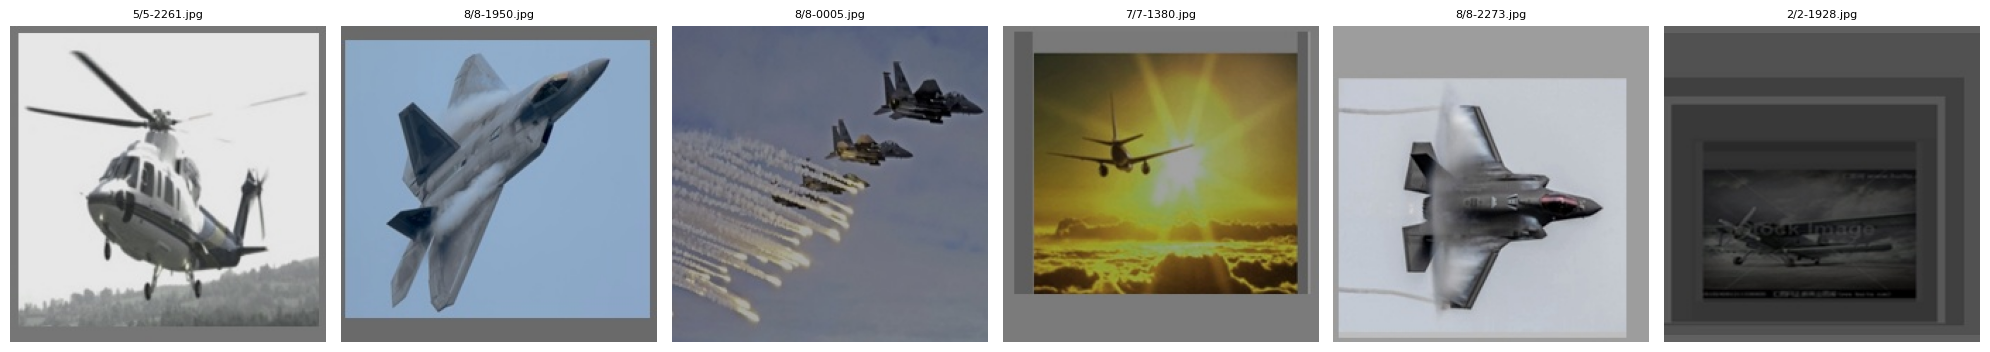


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/test) ---
Found 2305 images in /root/.cache/kagglehub/datasets/sleppyfish/aircraft-classification-dataset/versions/1/test. Displaying 6 samples:


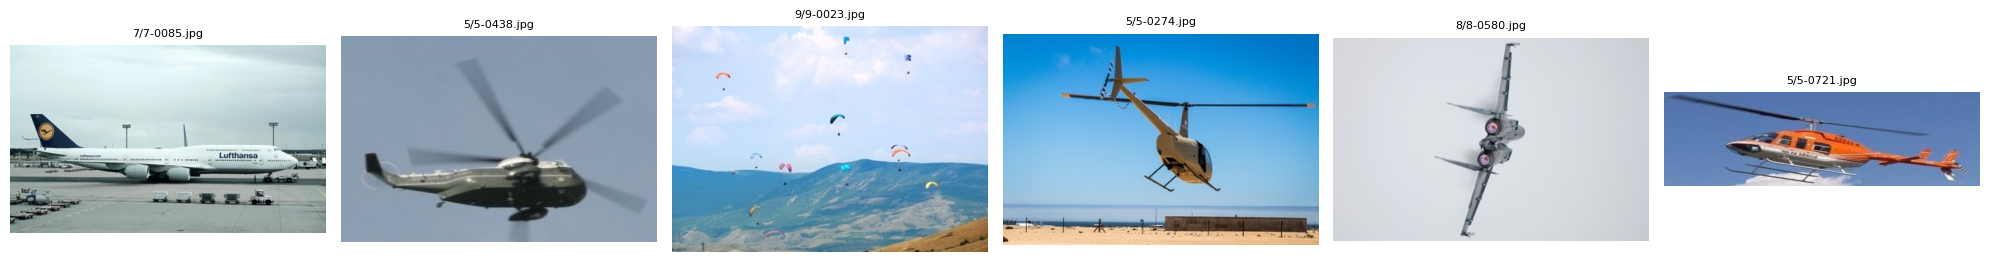

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig) # Close empty figure if no samples
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Display sample images from the 'train' directory
train_path = os.path.join(path, 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

# Display sample images from the 'test' directory
test_path = os.path.join(path, 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# Data transformation for ResNet
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(path, 'train'), data_transforms['train']),
    'test': datasets.ImageFolder(os.path.join(path, 'test'), data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=2)
}

class_names = image_datasets['train'].classes
print(f"Classes: {class_names}")

Classes: ['1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
# Build ResNet Model
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
# Adjusting for the number of classes in the dataset
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(num_epochs):
    for phase in ['train', 'test']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f'Epoch {epoch+1}/{num_epochs} | {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Epoch 1/10 | train Loss: 0.5586 Acc: 0.8121
Epoch 1/10 | test Loss: 0.4387 Acc: 0.8590
Epoch 2/10 | train Loss: 0.2635 Acc: 0.9103
Epoch 2/10 | test Loss: 0.3541 Acc: 0.8915
Epoch 3/10 | train Loss: 0.1648 Acc: 0.9455
Epoch 3/10 | test Loss: 0.2568 Acc: 0.9171
Epoch 4/10 | train Loss: 0.1349 Acc: 0.9566
Epoch 4/10 | test Loss: 0.1920 Acc: 0.9393
Epoch 5/10 | train Loss: 0.0887 Acc: 0.9715
Epoch 5/10 | test Loss: 0.2640 Acc: 0.9275
Epoch 6/10 | train Loss: 0.1023 Acc: 0.9669
Epoch 6/10 | test Loss: 0.1583 Acc: 0.9544
Epoch 7/10 | train Loss: 0.0760 Acc: 0.9760
Epoch 7/10 | test Loss: 0.1187 Acc: 0.9675
Epoch 8/10 | train Loss: 0.0735 Acc: 0.9767
Epoch 8/10 | test Loss: 0.1425 Acc: 0.9605
Epoch 9/10 | train Loss: 0.0714 Acc: 0.9767
Epoch 9/10 | test Loss: 0.1325 Acc: 0.9610
Epoch 10/10 | train Loss: 0.0595 Acc: 0.9815
Epoch 10/10 | test Loss: 0.1753 Acc: 0.9492


In [ ]:
# Summary of training results
print("--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")
print(f"Lowest Test Loss: {min(history['test_loss']):.4f}")

--- Training Summary ---
Final Training Accuracy: 0.9815
Final Test Accuracy: 0.9492
Lowest Test Loss: 0.1187


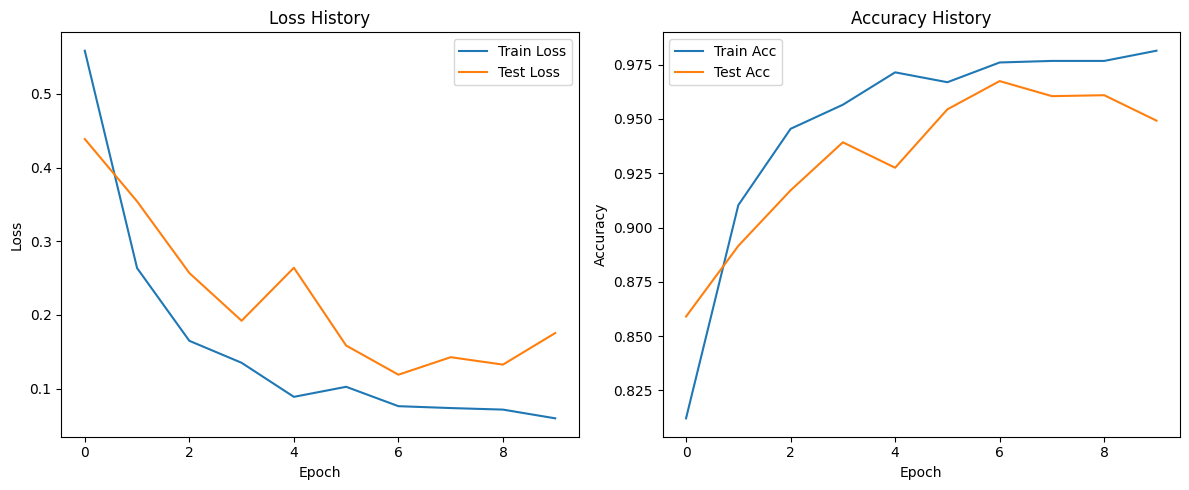

In [ ]:
# Plot Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()